In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timedelta

from enum import Enum, IntEnum, StrEnum
from dataclasses import dataclass, field

import json, requests, asyncio
from hyperliquid.info import Info
from hyperliquid.utils import constants

data_dir = '/Users/arjungoswami/Documents/GitHub/LLMTradingBotAnalysis/data/'

In [2]:
# %pip install hyperliquid-python-sdk

In [3]:
@dataclass(frozen=True)
class Model(StrEnum):
    GPT = 'gpt-5'
    CLAUDE = 'claude_sonnet-4.5'
    DEEPSEEK = 'deepseek_chat-v3.1'
    GEMINI = 'gemini-2.5-pro'
    GROK = 'grok-4'
    QWEN = 'qwen3-30b'

MODEL_WALLET_ADDRESSES = {
    Model.GPT.value: '0x67293d914eafb26878534571add81f6bd2d9fe06',
    Model.CLAUDE.value: '0x59fa085d106541a834017b97060bcbbb0aa82869', 
    Model.DEEPSEEK.value: '0xc20ac4dc4188660cbf555448af52694ca62b0734',
    Model.GEMINI.value: '0x1b7a7d099a670256207a30dd0ae13d35f278010f', 
    Model.GROK.value: '0x56d652e62998251b56c8398fb11fcfe464c08f84', 
    Model.QWEN.value: '0x7a8fd8bba33e37361ca6b0cb4518a44681bad2f3',
}

In [4]:
class LLMTradingBot:
    
    def __init__(self, model: Model, initial_amount: float=10_000.0):
        self.model = model
        self.initial_amount = initial_amount

    def get_wallet_address(self):
        return MODEL_WALLET_ADDRESSES[self.model.value]

    def get_historical_fill_data(self):
        info = Info()
        fill_data = info.user_fills(self.get_wallet_address())
        fill_data = pd.DataFrame(fill_data)
        fill_data['timestamp'] = [datetime.fromtimestamp(unix_timestamp/1e3) for unix_timestamp in fill_data['time'].astype(int)]
        fill_data.set_index('timestamp', inplace=True)
        fill_data.sort_index(inplace=True)
        fill_data.drop(columns=['time'], inplace=True)
        fill_data['cumPnl'] = np.cumsum(fill_data['closedPnl'].astype(float))
        fill_data['nav'] = fill_data['cumPnl'] + self.initial_amount
        fill_data['px'] = fill_data['px'].astype(float)
        fill_data['sz'] = fill_data['sz'].astype(float)
        fill_data['notional_trading_volume'] = np.abs(fill_data['px'] * fill_data['sz'])
        return fill_data

    def get_historical_pnl(self):
        return self.get_historical_fill_data()['cumPnl'] + self.initial_amount

    def plot_historical_pnl(self, ax=None):
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(self.get_historical_pnl() / 1e3, label=self.model.value)
        ax.legend()
        ax.tick_params(axis='x', rotation=45)
        ax.set_ylabel('$K USD')
        plt.title('cumulative PnL')
        return ax

    def get_percent_daily_turnover(self):
        fill_data = self.get_historical_fill_data()
        return 100.0 * fill_data['notional_trading_volume'].resample('D').sum() / fill_data['nav'].resample('D').mean().ffill()

    def plot_percent_daily_turnover(self, ax=None):
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 5))
        pct_daily_turnover = self.get_percent_daily_turnover()
        ax.plot(pct_daily_turnover, 'o--', label=self.model.value)
        ax.legend()
        ax.tick_params(axis='x', rotation=45)
        ax.set_ylabel('%')
        plt.title('Portfolio % Daily Turnover')
        return ax

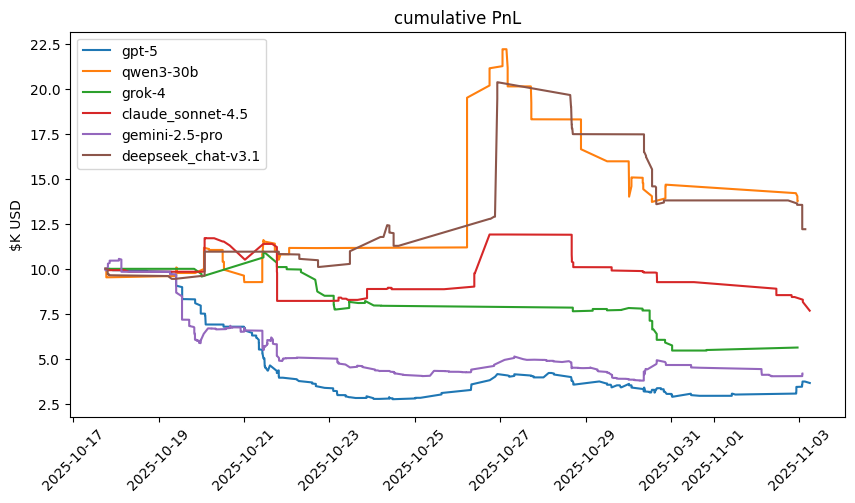

In [5]:
gpt_bot = LLMTradingBot(model=Model.GPT)
qwen_bot = LLMTradingBot(model=Model.QWEN)
grok_bot = LLMTradingBot(model=Model.GROK)
claude_bot = LLMTradingBot(model=Model.CLAUDE)
gemini_bot = LLMTradingBot(model=Model.GEMINI)
deepseek_bot = LLMTradingBot(model=Model.DEEPSEEK)

bots = [gpt_bot, qwen_bot, grok_bot, claude_bot, gemini_bot, deepseek_bot]

fig, ax = plt.subplots(figsize=(10, 5))
for bot in bots:
    bot.plot_historical_pnl(ax=ax)
plt.show()

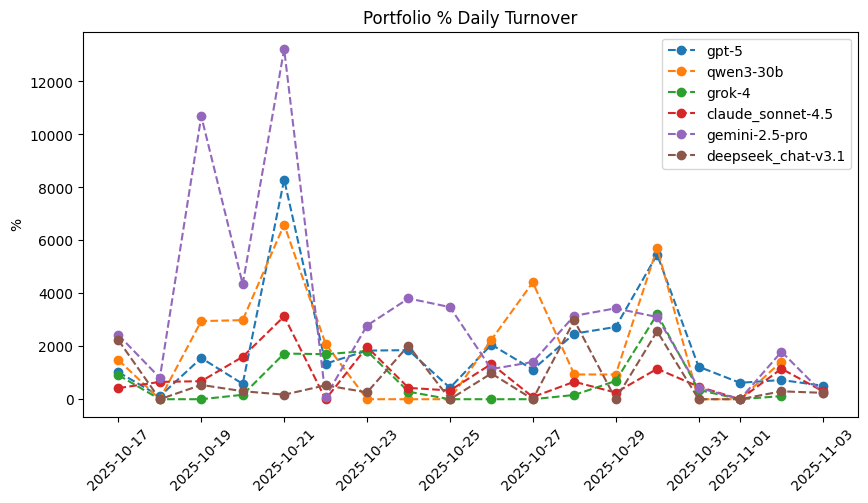

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
for bot in bots:
    bot.plot_percent_daily_turnover(ax=ax)
plt.show()

In [7]:
fill_data = deepseek_bot.get_historical_fill_data()
print(fill_data.columns)
fill_data

Index(['coin', 'px', 'sz', 'side', 'startPosition', 'dir', 'closedPnl', 'hash',
       'oid', 'crossed', 'fee', 'tid', 'feeToken', 'twapId', 'liquidation',
       'cumPnl', 'nav', 'notional_trading_volume'],
      dtype='object')


,coin,px,sz,side,startPosition,dir,closedPnl,hash,oid,crossed,fee,tid,feeToken,twapId,liquidation,cumPnl,nav,notional_trading_volume
timestamp,,,,,,,,,,,,,,,,,,
2025-10-17 18:14:46.005,BTC,107146.00,0.10059,A,0.0,Open Short,0.0,0x710eb63ac14493c27288042dadc60202018200205c47...,204606925687,True,4.850017,95788746437357,USDC,None,NaN,0.000000,10000.000000,10777.81614
2025-10-17 18:14:46.005,BTC,107146.00,0.00011,A,-0.10059,Open Short,0.0,0x710eb63ac14493c27288042dadc60202018200205c47...,204606925687,True,0.005303,725690248891225,USDC,None,NaN,0.000000,10000.000000,11.78606
2025-10-17 18:14:46.005,BTC,107146.00,0.10930,A,-0.1007,Open Short,0.0,0x710eb63ac14493c27288042dadc60202018200205c47...,204606925687,True,5.269976,135556538554213,USDC,None,NaN,0.000000,10000.000000,11711.05780
2025-10-17 18:43:13.714,BNB,1076.60,8.36000,B,0.0,Open Long,0.0,0x965d5291652da22d97d7042dae1a8b02020300770020...,204624767080,True,4.050169,903777859081016,USDC,None,NaN,0.000000,10000.000000,9000.37600
2025-10-17 18:43:13.714,BNB,1076.60,0.94000,B,8.36,Open Long,0.0,0x965d5291652da22d97d7042dae1a8b02020300770020...,204624767080,True,0.455401,82372982269813,USDC,None,NaN,0.000000,10000.000000,1012.00400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-02 23:00:08.767,SOL,177.22,66.34000,B,12.84,Open Long,0.0,0x2c17a99cbd00067b2d91042ebc14ab02139100825803...,220730764131,True,4.702709,743845443038164,USDC,None,NaN,3551.873401,13551.873401,11756.77480
2025-11-03 01:48:01.131,BNB,1026.30,0.05000,A,23.05,Close Long,-2.78995,0x1bfe6eac7b36c4341d78042ebe075d020d7200921639...,215309797967,False,0.006157,299786484692839,USDC,None,NaN,3549.083451,13549.083451,51.31500
2025-11-03 01:48:36.782,BNB,1023.40,23.00000,A,23.0,Close Long,-1350.077,0xde9f3aecb6cfce90e018042ebe090401100052d251c2...,220868199559,True,9.41528,847430279690317,USDC,None,{'liquidatedUser': '0xc20ac4dc4188660cbf555448...,2199.006451,12199.006451,23538.20000


In [8]:
btc_prices = pd.read_csv(data_dir + 'BTC_USDT_1m_30d.csv')
btc_prices

,timestamp,open,high,low,close,volume
0,2025-09-29 22:35:00,114090.52,114090.52,114041.92,114041.93,3.23364
1,2025-09-29 22:36:00,114041.92,114041.93,114037.48,114037.48,3.52008
2,2025-09-29 22:37:00,114037.49,114037.49,114037.48,114037.49,1.31498
3,2025-09-29 22:38:00,114037.48,114037.49,114037.47,114037.48,2.78636
4,2025-09-29 22:39:00,114037.48,114037.48,114020.00,114020.00,12.38574
...,...,...,...,...,...,...
43196,2025-10-29 22:31:00,111182.01,111199.81,111150.01,111156.40,12.90429
43197,2025-10-29 22:32:00,111156.40,111210.60,111156.39,111210.59,4.09702
43198,2025-10-29 22:33:00,111210.59,111210.59,111170.48,111170.48,2.86821
43199,2025-10-29 22:34:00,111170.49,111180.15,111156.93,111156.94,1.32202
